### Binary Classifier for ANY Category
Relevant Statistics: 

In [14]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('../Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('../Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [11]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df['any'].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

# Create datasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [4]:
# Define a PyTorch binary classification model
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, neurons=128, dropout_rate=0.3):
        super(BinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, neurons)
        self.bn1 = nn.BatchNorm1d(neurons)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.out = nn.Linear(neurons, 1)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.out(x)
        return torch.sigmoid(x)


In [7]:
# Set device, create model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BinaryClassifier(input_dim=X_train_tensor.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [12]:
# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 1/50, Loss: 0.4346
Epoch 2/50, Loss: 0.4159
Epoch 3/50, Loss: 0.4058
Epoch 4/50, Loss: 0.4020
Epoch 5/50, Loss: 0.3956
Epoch 6/50, Loss: 0.3911
Epoch 7/50, Loss: 0.3938
Epoch 8/50, Loss: 0.3883
Epoch 9/50, Loss: 0.3856
Epoch 10/50, Loss: 0.3860
Epoch 11/50, Loss: 0.3837
Epoch 12/50, Loss: 0.3847
Epoch 13/50, Loss: 0.3805
Epoch 14/50, Loss: 0.3777
Epoch 15/50, Loss: 0.3819
Epoch 16/50, Loss: 0.3755
Epoch 17/50, Loss: 0.3782
Epoch 18/50, Loss: 0.3777
Epoch 19/50, Loss: 0.3749
Epoch 20/50, Loss: 0.3714
Epoch 21/50, Loss: 0.3722
Epoch 22/50, Loss: 0.3693
Epoch 23/50, Loss: 0.3715
Epoch 24/50, Loss: 0.3703
Epoch 25/50, Loss: 0.3709
Epoch 26/50, Loss: 0.3705
Epoch 27/50, Loss: 0.3670
Epoch 28/50, Loss: 0.3626
Epoch 29/50, Loss: 0.3677
Epoch 30/50, Loss: 0.3637
Epoch 31/50, Loss: 0.3666
Epoch 32/50, Loss: 0.3643
Epoch 33/50, Loss: 0.3631
Epoch 34/50, Loss: 0.3628
Epoch 35/50, Loss: 0.3643
Epoch 36/50, Loss: 0.3633
Epoch 37/50, Loss: 0.3652
Epoch 38/50, Loss: 0.3613
Epoch 39/50, Loss: 0.

In [15]:
# Evaluation
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        y_pred.append(outputs.cpu().numpy())
        y_true.append(yb.numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
auc = roc_auc_score(y_true, y_pred)
print("Test AUC:", auc)
y_pred_binary = (y_pred > 0.5).astype(int)
print(classification_report(y_true, y_pred_binary))

Test AUC: 0.9091378350433468
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1905
         1.0       0.83      0.78      0.80      1320

    accuracy                           0.84      3225
   macro avg       0.84      0.83      0.84      3225
weighted avg       0.84      0.84      0.84      3225



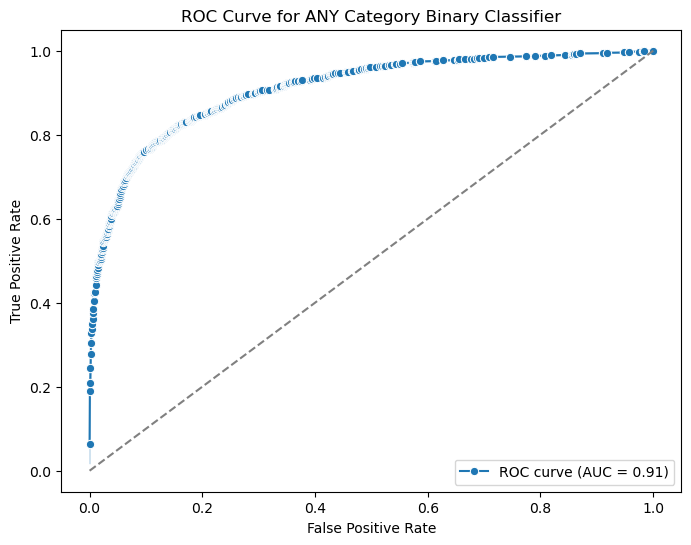

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate the False Positive Rate and True Positive Rate for the ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.step(fpr, tpr, where='post', label=f'ROC curve (AUC = {auc:.2f})')
plt.fill_between(fpr, tpr, step='post', alpha=0.1, color='b')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ANY Category Binary Classifier')
plt.legend(loc='lower right')
plt.show()